In [1]:
pip install selenium

  Using cached trio-0.32.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 1.3 MB/s  0:00:07a 0:00:010:00:01:02
Using cached trio-0.32.0-py3-none-any.whl (512 kB)
Using cached trio_websocket-0.12.2-py3-none-any.whl (21 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
Using cached outcome-1.3.0.post0-py2.py3-none-any.whl (10 kB)
Using cached wsproto-1.3.2-py3-none-any.whl (24 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
  Attempting uninstall: urllib3
    Found existing

In [1]:
import requests
from bs4 import BeautifulSoup

website_link = 'https://techcrunch.com/latest'
links = []
page_limit = 30  # max pages
page_count = 1

while page_count <= page_limit:
    if page_count == 1:
        url = website_link
    else:
        url = f"{website_link}/page/{page_count}/"
    
    r = requests.get(url, timeout=10)
    if r.status_code != 200:
        print(f"Failed to fetch page {page_count}, stopping.")
        break

    soup = BeautifulSoup(r.text, 'html.parser')
    articles_list = soup.select(".wp-block-post")

    if not articles_list:
        print(f"No articles found on page {page_count}, stopping.")
        break

    for article_item in articles_list:
        link_tag = article_item.select_one("h3 a")
        if link_tag:
            href = link_tag.get("href")
            if href and href not in links:
                links.append(href)

    print(f"Page {page_count} scraped, found {len(articles_list)} articles.")
    page_count += 1

print(f"Total links collected: {len(links)}")


Page 1 scraped, found 27 articles.
Page 2 scraped, found 27 articles.
Page 3 scraped, found 27 articles.
Page 4 scraped, found 27 articles.
Page 5 scraped, found 27 articles.
Page 6 scraped, found 27 articles.
Page 7 scraped, found 27 articles.
Page 8 scraped, found 27 articles.
Page 9 scraped, found 27 articles.
Page 10 scraped, found 27 articles.
Page 11 scraped, found 27 articles.
Page 12 scraped, found 27 articles.
Page 13 scraped, found 27 articles.
Page 14 scraped, found 27 articles.
Page 15 scraped, found 27 articles.
Page 16 scraped, found 27 articles.
Page 17 scraped, found 27 articles.
Page 18 scraped, found 27 articles.
Page 19 scraped, found 27 articles.
Page 20 scraped, found 27 articles.
Page 21 scraped, found 27 articles.
Page 22 scraped, found 27 articles.
Page 23 scraped, found 27 articles.
Page 24 scraped, found 27 articles.
Page 25 scraped, found 27 articles.
Page 26 scraped, found 27 articles.
Page 27 scraped, found 27 articles.
Page 28 scraped, found 27 articles.
P

In [2]:
def extract_article_data(html_source):
    """
    Parses HTML to extract metadata and structured body text.
    Ensures no 'NoneType' errors if elements are missing.
    """
    soup = BeautifulSoup(html_source, 'html.parser')
    
    # 1. Metadata Extraction with safety checks
    title_tag = soup.select_one(".article-hero__title")
    title = title_tag.get_text(strip=True) if title_tag else "Unknown Title"
    
    date_tag = soup.select_one("time")
    # Using 'datetime' attribute is better for Data Science / Time Series analysis
    date = date_tag['datetime'] if date_tag and date_tag.has_attr('datetime') else "N/A"
    
    author_tag = soup.select_one(".wp-block-tc23-author-card-name__link")
    author = author_tag.get_text(strip=True) if author_tag else "Unknown Author"

    tags = soup.select(".tc23-post-relevant-terms__terms a")
    tag_list = [tag.get_text(strip=True) for tag in tags] if tags else []

    # 2. Body Extraction (Targeting the specific WordPress content block)
    content_div = soup.find("div", class_="wp-block-post-content")
    body_text = ""
    
    if content_div:
        # removing cta section from the article
        for cta in content_div.find_all("div", class_= "inline-cta__content"):
            cta.decompose()
        # We only want meaningful text tags to avoid ads and scripts
        tags = ["p", "h1", "h2", "h3", "h4", "h5", "li"]
        paragraphs = [t.get_text(strip=True) for t in content_div.find_all(tags)]
        body_text = "\n\n".join(paragraphs)
        
    return  {
        "url": url,
        "source": "techcrunch",
        "title": title,
        "author": author,        
        "published_at": date,
        "content": body_text,
        "tags": tag_list,
        "error": None,
    }

   

all_data = []

for link in links:
    try:
        # Using a 10s timeout is a 'Best Practice' for robust scrapers
        response = requests.get(link, timeout=10)
        response.raise_for_status() # Raises an error for 404 or 500 status codes
        
        # Call the function and add the URL for traceability
        article_info = extract_article_data(response.text)
        article_info['url'] = link
        
        all_data.append(article_info)
        print(f"Successfully scraped: {article_info['title'][:50]}...")

    except Exception as e:
        # Important for the 'Scientific Report': Log why a link failed
        print(f"Skipping {link} due to error: {e}")

# Save to CSV (Final Deliverable requirement)
import pandas as pd
df = pd.DataFrame(all_data)
df.to_csv("../data/raw/tech_watch_raw_data.csv", index=False)

Successfully scraped: Music publishers sue Anthropic for $3B over ‘flagr...
Successfully scraped: India is teaching Google how AI in education can s...
Successfully scraped: Unknown Title...
Successfully scraped: Tesla’s energy storage business is growing faster ...
Successfully scraped: Unknown Title...
Successfully scraped: Apple’s new iPhone and iPad security feature limit...
Successfully scraped: Google Maps now lets you access Gemini while walki...
Successfully scraped: Waymo robotaxi hits a child near an elementary sch...
Successfully scraped: Upwind raises $250M at $1.5B valuation to continue...
Successfully scraped: Unknown Title...
Successfully scraped: Deezer makes it easier for rival platforms to take...
Successfully scraped: Meta burned $19 billion on VR last year, and 2026 ...
Successfully scraped: Zuckerberg teases agentic commerce tools and major...
Successfully scraped: Unknown Title...
Successfully scraped: Microsoft gained $7.6B from OpenAI last quarter...
Successfull

In [70]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# --- 1. SETUP & DOWNLOADS ---
# These are the dictionary files NLTK needs to understand English
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # A. Macro Clean: Remove URLs, special characters, and numbers
    # We use Regular Expressions (Regex) for this
    text = re.sub(r'http\S+', '', text)  # Remove links
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove everything except letters
    
    # B. Normalization: Lowercase
    text = text.lower()
    
    # C. Tokenization: Split into individual words
    tokens = word_tokenize(text)
    
    # D. Stop-word Removal
    # We get the standard English list and add "Custom" words found in tech news
    stop_words = set(stopwords.words('english'))
    custom_stops = {'techcrunch', 'read', 'more', 'image', 'source', 'subscribe', 'newsletter', 'said', 'also', 'first', 'company', 'disrupt', 'waitlist', 'one', 'two', 'told', 'says'}
    stop_words.update(custom_stops)
    
    tokens = [w for w in tokens if w not in stop_words]
    
    # E. Lemmatization: Convert words to their root (e.g., "running" -> "run")
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    # F. Reconstruct the text
    return " ".join(tokens)

# --- 2. EXECUTION ---

# Load the dataset you scraped
df = pd.read_csv("tech_watch_raw_data.csv")

print("Starting cleaning process... this may take a minute.")

# Apply the function to create a new column
df['cleaned_body'] = df['body'].apply(clean_text)

# Remove any rows that ended up empty after cleaning
df = df[df['cleaned_body'] != ""]

# Save the "Exploitable Dataset" (as required by your PFM)
df.to_csv("tech_watch_cleaned_data.csv", index=False)

print("Cleaning complete! Ready for LDA modeling.")
print("\nExample of cleaned text:")
print(df['cleaned_body'].iloc[0][:200] + "...")

[nltk_data] Downloading package punkt to /Users/Apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/Apple/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/Apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/Apple/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/Apple/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Starting cleaning process... this may take a minute.
Cleaning complete! Ready for LDA modeling.

Example of cleaned text:
last year fusion power startup general fusion struggling raise fund laying offat least staffbeforereceiving million lifeline investmentwhile figured keep afloat today general fusion revealed survival ...


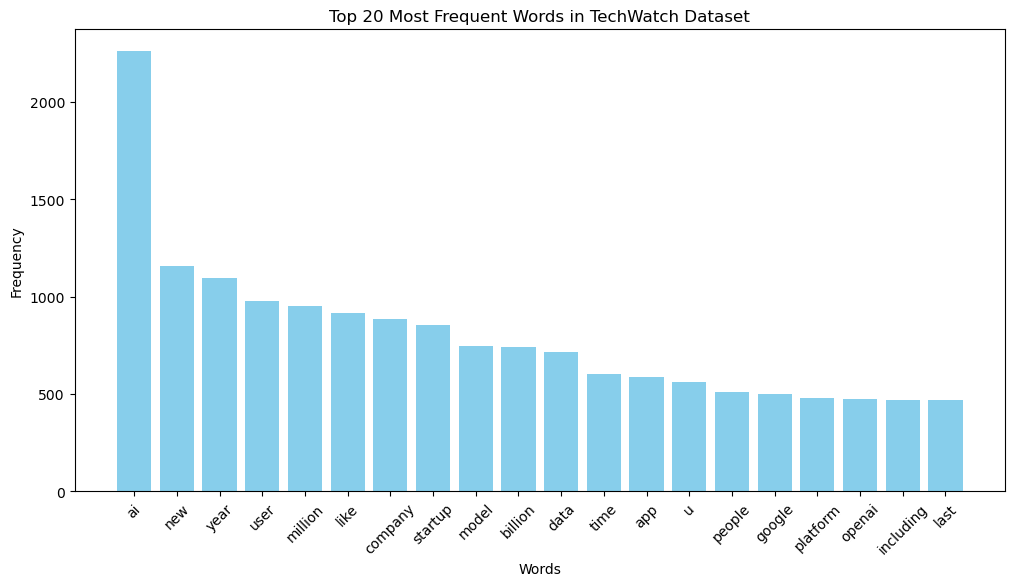

Top 10 Words found: [('ai', 2259), ('new', 1157), ('year', 1095), ('user', 979), ('million', 954), ('like', 915), ('company', 887), ('startup', 855), ('model', 745), ('billion', 744)]


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Load your cleaned data
df = pd.read_csv("tech_watch_cleaned_data.csv")

# 2. Combine all cleaned text into one giant list of words
all_words = " ".join(df['cleaned_body']).split()

# 3. Count frequencies
word_freq = Counter(all_words)
common_words = word_freq.most_common(20) # Top 20

# 4. Convert to a small DataFrame for plotting
top_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

# 5. Create the Visualization (Crucial for your PFM report!)
plt.figure(figsize=(12, 6))
plt.bar(top_df['Word'], top_df['Count'], color='skyblue')
plt.title('Top 20 Most Frequent Words in TechWatch Dataset')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.xlabel('Words')
plt.show()

# Print the list for your report
print("Top 10 Words found:", common_words[:10])

In [72]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Load your cleaned data
df = pd.read_csv("tech_watch_cleaned_data.csv")

# 2. Vectorization: Convert text to a matrix of word counts
# We limit to the top 1000 words to keep the model focused
vectorizer = CountVectorizer(max_features=1000, min_df=5, max_df=0.9)
data_vectorized = vectorizer.fit_transform(df['cleaned_body'])

# 3. Create the LDA Model
# n_components = the number of topics you want to find (let's try 5)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10)
lda_output = lda_model.fit_transform(data_vectorized)

# 4. Extract and Display the Trends
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n--- Trend {topic_idx + 1} ---")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

# Get the names of the words
tf_feature_names = vectorizer.get_feature_names_out()

# Show the top 10 words for each of the 5 trends
display_topics(lda_model, tf_feature_names, 10)


--- Trend 1 ---
ai openai model chatgpt google new apple company chip employee

--- Trend 2 ---
user app new data time content like platform people social

--- Trend 3 ---
ai like new model app device feature use year vehicle

--- Trend 4 ---
million billion raised round startup ai investor series funding capital

--- Trend 5 ---
year startup ai company data power new technology founder like


In [73]:
# Get the dominant topic for each document
# This takes the LDA output (probabilities) and finds the highest one
dominant_topics = lda_output.argmax(axis=1) + 1 # +1 to match Trend 1-5 numbering

# Add the trend labels to your dataframe
df['dominant_trend'] = dominant_topics

# Map the labels for a cleaner CSV
trend_map = {
    1: "Generative AI",
    2: "Social & UX",
    3: "AI Hardware/Apps",
    4: "VC & Funding",
    5: "Business Ecosystem"
}
df['trend_label'] = df['dominant_trend'].map(trend_map)

# Save the final masterpiece
df.to_csv("tech_watch_final_results.csv", index=False)

# Final EDA: Show the distribution
print(df['trend_label'].value_counts())

trend_label
Business Ecosystem    170
Social & UX           165
AI Hardware/Apps      126
Generative AI          81
VC & Funding           48
Name: count, dtype: int64


/var/folders/dx/fpvxs28s3jvgngq5gtt1prpm0000gn/T/ipykernel_88451/1871786426.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period'] = df['date'].dt.to_period('D')


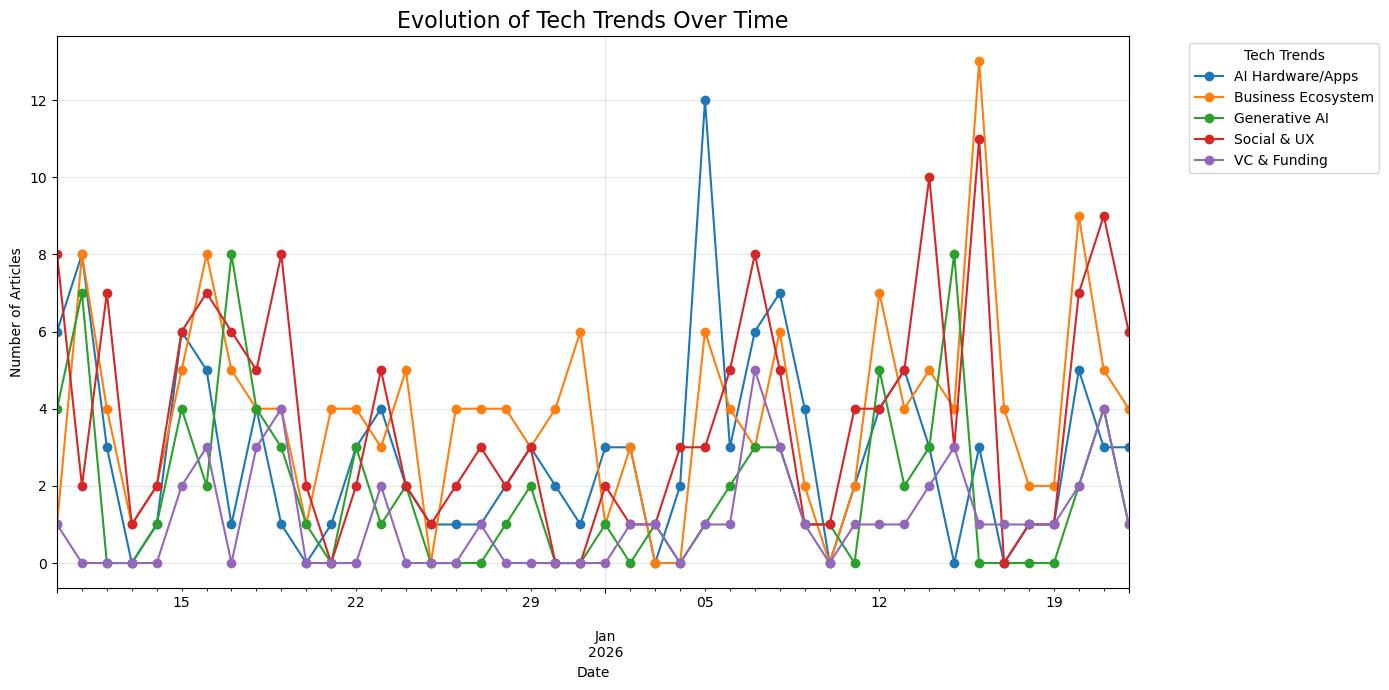

In [74]:
import matplotlib.pyplot as plt

# 1. Convert 'date' to actual datetime objects
df['date'] = pd.to_datetime(df['date'])

# 2. Extract only the Month/Year or Day for grouping
# Resampling by Week ('W') or Day ('D') is best for short-term watches
df['period'] = df['date'].dt.to_period('D') 

# 3. Create a pivot table: Rows = Period, Columns = Trends, Values = Count of articles
evolution_df = df.groupby(['period', 'trend_label']).size().unstack(fill_value=0)

# 4. Plotting the Trend Evolution
plt.figure(figsize=(14, 7))
evolution_df.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Evolution of Tech Trends Over Time', fontsize=16)
plt.ylabel('Number of Articles')
plt.xlabel('Date')
plt.legend(title='Tech Trends', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
# Final export for the jury
df.to_csv("PFM_Final_TechWatch_Data.csv", index=False)